<a href="https://colab.research.google.com/github/Aditya12340/ScrewSorter/blob/main/ScrewClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install torch torchvision opencv-contrib-python pillow matplotlib

In [ ]:
# Cell 2: Imports + setup
import os
import cv2
import json
import math
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


In [ ]:
# Cell 3: Upload exactly 3 base images (one per class)
# After upload, you'll map each filename to class name.

uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))


Saving Flat_Head_Screws.png to Flat_Head_Screws.png
Saving Oval_Head_Screw.jpg to Oval_Head_Screw.jpg
Saving Round_Washer_Head.jpg to Round_Washer_Head.jpg
Uploaded files: ['Flat_Head_Screws.png', 'Oval_Head_Screw.jpg', 'Round_Washer_Head.jpg']


In [ ]:
# Cell 4: Map uploaded files to your class names
# IMPORTANT: edit this dictionary keys to match your uploaded filenames exactly.

# Example:
# class_map = {
#   "flat.jpg": "flat_head",
#   "pan.jpg": "pan_head",
#   "hex.jpg": "hex_head",
# }

class_map = {
     "Flat_Head_Screws.png": "Flat_Head",
     "Oval_Head_Screw.jpg": "Oval_Head",
     "Round_Washer_Head.jpg": "Round_Washer"
}

assert len(class_map) == 3, "Please map exactly 3 uploaded files to 3 class names."
assert len(set(class_map.values())) == 3, "Class names must be 3 unique values."

print("Class map:")
for k,v in class_map.items():
    print(f"  {k} -> {v}")

Class map:
  Flat_Head_Screws.png -> Flat_Head
  Oval_Head_Screw.jpg -> Oval_Head
  Round_Washer_Head.jpg -> Round_Washer


In [ ]:
# Cell 5: Build synthetic dataset from only 3 base images

ROOT = "screw_data"
TRAIN_DIR = os.path.join(ROOT, "train")
VAL_DIR = os.path.join(ROOT, "val")

# Clean old dataset
if os.path.exists(ROOT):
    shutil.rmtree(ROOT)

classes = sorted(list(set(class_map.values())))
for split in [TRAIN_DIR, VAL_DIR]:
    for c in classes:
        os.makedirs(os.path.join(split, c), exist_ok=True)

def augment_image(img_bgr, out_size=224):
    """
    img_bgr: numpy image
    returns augmented BGR image (224x224)
    """
    h, w = img_bgr.shape[:2]

    # Random rotate
    angle = random.uniform(-25, 25)
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, random.uniform(0.9, 1.1))
    aug = cv2.warpAffine(img_bgr, M, (w, h), borderMode=cv2.BORDER_REFLECT101)

    # Random crop-ish via scaling then resize back
    scale = random.uniform(0.75, 1.0)
    nh, nw = int(h*scale), int(w*scale)
    y0 = random.randint(0, h - nh) if h - nh > 0 else 0
    x0 = random.randint(0, w - nw) if w - nw > 0 else 0
    aug = aug[y0:y0+nh, x0:x0+nw]

    # Brightness/contrast
    alpha = random.uniform(0.8, 1.25)  # contrast
    beta = random.uniform(-25, 25)     # brightness
    aug = cv2.convertScaleAbs(aug, alpha=alpha, beta=beta)

    # Slight blur sometimes
    if random.random() < 0.3:
        k = random.choice([3,5])
        aug = cv2.GaussianBlur(aug, (k,k), 0)

    # Random horizontal flip
    if random.random() < 0.5:
        aug = cv2.flip(aug, 1)

    aug = cv2.resize(aug, (out_size, out_size))
    return aug

# You can tune these:
TRAIN_PER_CLASS = 100
VAL_PER_CLASS = 5

for fname, cls in class_map.items():
    base = cv2.imread(fname)
    if base is None:
        raise ValueError(f"Could not read uploaded file: {fname}")

    # Ensure reasonable base size
    base = cv2.resize(base, (320, 320))

    # Generate train
    for i in range(TRAIN_PER_CLASS):
        aug = augment_image(base, out_size=224)
        cv2.imwrite(os.path.join(TRAIN_DIR, cls, f"{cls}_train_{i:04d}.jpg"), aug)

    # Generate val
    for i in range(VAL_PER_CLASS):
        aug = augment_image(base, out_size=224)
        cv2.imwrite(os.path.join(VAL_DIR, cls, f"{cls}_val_{i:04d}.jpg"), aug)

print("Dataset created.")
for split in [TRAIN_DIR, VAL_DIR]:
    print("\n", split)
    for c in classes:
        n = len(os.listdir(os.path.join(split, c)))
        print(f"  {c}: {n}")

Dataset created.

 screw_data/train
  Flat_Head: 100
  Oval_Head: 100
  Round_Washer: 100

 screw_data/val
  Flat_Head: 5
  Oval_Head: 5
  Round_Washer: 5


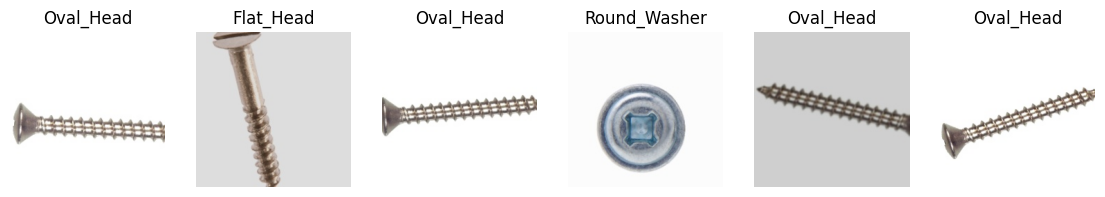

In [ ]:
import glob

def show_samples(split_dir, n=6):
    paths = glob.glob(os.path.join(split_dir, "*", "*.jpg"))
    picks = random.sample(paths, min(n, len(paths)))
    plt.figure(figsize=(14, 4))
    for i, p in enumerate(picks, 1):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        cls = p.split("/")[-2]
        plt.subplot(1, len(picks), i)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    plt.show()

show_samples(TRAIN_DIR, n=6)
#Training Set

In [ ]:
BATCH_SIZE = 32
EPOCHS = 6
LR = 1e-4

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds = datasets.ImageFolder(VAL_DIR, transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("class_to_idx:", train_ds.class_to_idx)

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 3)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = 0.0
for epoch in range(EPOCHS):
    # train
    model.train()
    tr_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()

    # val
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {tr_loss/len(train_loader):.4f} - val_acc: {val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_ds.class_to_idx
        }, "screw_classifier.pt")
        print("  saved best -> screw_classifier.pt")

print("Best val acc:", best_val)

class_to_idx: {'Flat_Head': 0, 'Oval_Head': 1, 'Round_Washer': 2}
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 78.9MB/s]


Epoch 1/6 - train_loss: 0.5963 - val_acc: 1.0000
  saved best -> screw_classifier.pt
Epoch 2/6 - train_loss: 0.0952 - val_acc: 1.0000
Epoch 3/6 - train_loss: 0.0248 - val_acc: 1.0000
Epoch 4/6 - train_loss: 0.0136 - val_acc: 1.0000
Epoch 5/6 - train_loss: 0.0098 - val_acc: 1.0000
Epoch 6/6 - train_loss: 0.0089 - val_acc: 1.0000
Best val acc: 1.0


Upload test image:


Saving Brian.png to Brian.png
Prediction: Flat_Head
Confidence: 0.47379806637763977
Probabilities:
  Flat_Head: 0.4738
  Oval_Head: 0.2463
  Round_Washer: 0.2799


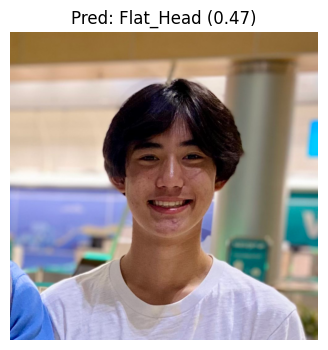

In [ ]:
from PIL import Image

ckpt = torch.load("screw_classifier.pt", map_location=DEVICE)
idx_to_class = {v:k for k,v in ckpt["class_to_idx"].items()}

infer_model = models.mobilenet_v2(weights=None)
infer_model.classifier[1] = nn.Linear(infer_model.last_channel, 3)
infer_model.load_state_dict(ckpt["model_state_dict"])
infer_model.to(DEVICE).eval()

infer_tfm = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

print("Upload test image:")
up = files.upload()
test_name = next(iter(up.keys()))

img = Image.open(test_name).convert("RGB")
x = infer_tfm(img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = infer_model(x)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

pred_idx = int(np.argmax(probs))
print("Prediction:", idx_to_class[pred_idx])
print("Confidence:", float(probs[pred_idx]))
print("Probabilities:")
for i, p in enumerate(probs):
    print(f"  {idx_to_class[i]}: {p:.4f}")

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Pred: {idx_to_class[pred_idx]} ({probs[pred_idx]:.2f})")
plt.axis("off")
plt.show()

# New Section

In [ ]:

files.download("screw_classifier.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileUpload(value={}, accept='image/*', description='Upload')

Measured length: 6.912 mm
Measured length: 14.976 mm
Measured length: 11.712 mm
Measured length: 8.256 mm
Measured length: 21.312 mm
Measured length: 8.832 mm
Measured length: 19.584 mm
Measured length: 13.632 mm
Measured length: 5.952 mm
Measured length: 12.672 mm
Measured length: 10.176 mm
Measured length: 8.064 mm
Measured length: 42.432 mm
Measured length: 11.904 mm
Measured length: 32.64 mm


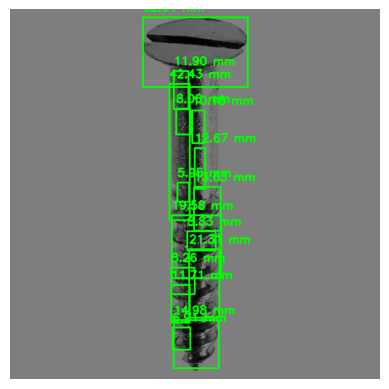

In [ ]:
import cv2
import numpy as np
from IPython.display import display
import ipywidgets as widgets
from PIL import Image
import io

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

def process_image(change):

    if len(uploader.value) == 0:
        return

    uploaded_file = list(uploader.value.values())[0]
    content = uploaded_file['content']

    image = Image.open(io.BytesIO(content))
    img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    scale = 0.192  # mm per pixel

    for c in contours:

        if cv2.contourArea(c) < 100:
            continue

        x, y, w, h = cv2.boundingRect(c)

        pixel_length = max(w, h)
        real_length = pixel_length * scale

        cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)

        label = f"{real_length:.2f} mm"

        cv2.putText(img, label, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0,255,0), 2)

        print("Measured length:", real_length, "mm")

    from matplotlib import pyplot as plt
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

uploader.observe(process_image, names='value')